In [1]:
%cd ..
!git clone https://github.com/dodo47/GCDetection

/home/ludi/Documents/Uni/magistrale/AII/AII-Assignment
fatal: destination path 'GCDetection' already exists and is not an empty directory.


Load the datasets using utils.data.prepare_data()

In [2]:
from torch.utils.data import Dataset, DataLoader

class FrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.frames = np.stack(df.frame.values)
        self.labels = np.array(df.y)
        self.transform =  transform

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        if self.transform:
            ch1 = self.transform(self.frames[idx][0])
            ch2 = self.transform(self.frames[idx][1])
            img = np.stack(ch1, ch2)
        else:
            img = self.frames[idx].astype('float32') #/ 255
            
        return torch.tensor(img).float(), torch.tensor(self.labels[idx])


In [3]:
from utils import data
import pandas as pd
import numpy as np
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

FCC, VCC = data.prepare_data()
all_frames = pd.concat((FCC, VCC))
all_frames = all_frames[~all_frames.frame.apply(lambda x: np.isnan(x).any())]

min_class_size = all_frames['y'].value_counts().min()

# Bilancia eseguendo un campionamento (senza rimpiazzo) per ogni classe
balanced_all_frames = (
    all_frames.groupby('y', group_keys=False)
    .apply(lambda x: x.sample(min_class_size, random_state=42))
)

# Ora procedi con lo split come prima
train_df = balanced_all_frames.sample(frac=0.7, random_state=42)
rest = balanced_all_frames.drop(train_df.index)
val_df = rest.sample(frac=1/3, random_state=42)
test_df = rest.drop(val_df.index)



train_ds = DataLoader(
    FrameDataset(train_df), 
    batch_size=64, # Molto più efficiente per la GPU
    shuffle=True,
    num_workers=4, # Carica i dati in parallelo su altri core CPU
    pin_memory=True # Velocizza il passaggio RAM -> GPU
)
val_ds = DataLoader(FrameDataset(val_df), batch_size=64, shuffle=False)
test_ds = DataLoader(FrameDataset(test_df), batch_size=64, shuffle=False)

cuda


/tmp/ipykernel_9273/4199119708.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_class_size, random_state=42))


In [4]:
print(train_ds.dataset[0])

(tensor([[[-9.7807e-04, -1.6828e-02, -1.2501e-02,  1.1937e-02,  4.4520e-03,
           2.2912e-05,  1.2233e-02,  2.8120e-02,  2.4967e-02, -7.0532e-03,
          -2.2152e-03,  9.5682e-04,  1.0264e-02,  7.0848e-03, -1.6276e-02,
          -6.8226e-03, -2.9781e-03,  6.5624e-03, -9.2831e-03,  1.3857e-02],
         [-2.1351e-02,  9.7777e-03,  1.1664e-02,  2.5588e-03,  2.4574e-02,
           1.8039e-02, -1.3282e-02, -2.3075e-02, -3.3225e-02, -6.1232e-03,
          -1.9392e-02,  3.6270e-04,  2.3939e-02,  2.4139e-02,  6.1195e-03,
          -4.5034e-03, -1.1575e-02,  1.2704e-02,  7.1459e-03,  4.3515e-03],
         [-7.5604e-03,  3.5898e-03,  2.1060e-02, -5.3639e-03,  1.5550e-02,
           8.4912e-03, -1.8516e-02, -3.0772e-02, -3.4346e-02, -4.8683e-03,
           2.0248e-02, -5.6353e-03,  3.3198e-02,  2.0833e-02,  1.1757e-02,
          -2.0468e-02, -1.6661e-02, -9.3185e-04, -2.9210e-02, -1.0265e-02],
         [ 1.2835e-02, -1.2830e-02, -1.4482e-02,  2.7103e-02,  2.0761e-02,
           1.1377e-02

/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])


Data Exploration

<Axes: xlabel='y', ylabel='Count'>

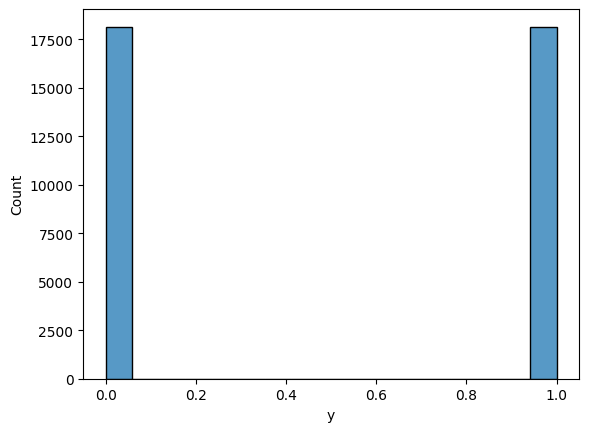

In [5]:
import seaborn as sns

sns.histplot(balanced_all_frames["y"])

In [6]:
from torch import nn
import torch.nn.functional as F
class ConvGp(nn.Module):
    def __init__(self, device, log_path, in_channels, out_channels, kernel_size, M, padding=0, stride=1, log_s=1.0, log_ls=1.0, name=None):
        super().__init__()
        self.k = kernel_size
        self.out_channels = out_channels
        self.P = in_channels * kernel_size * kernel_size 
        self.M = M 
        self.padding = padding
        self.stride = stride
        self.Z = nn.Parameter(torch.randn(M, self.P) * 0.1)
        
        # MODIFICA CRITICA: Scala lengthscale con √P
        # Per spazi ad alta dimensionalità, le distanze crescono come √P
        scale_factor = np.sqrt(self.P)
        
        self.log_s = nn.Parameter(torch.tensor(log_s))
        self.log_ls = nn.Parameter(torch.tensor(log_ls * scale_factor))
        
        self.name = name
        self.device = device
        self.log_path = log_path
    
    @property
    def sigma(self): 
        # Softplus is more stable than exp for scales
        return F.softplus(self.log_s)

    @property
    def lengthscale(self): 
        return F.softplus(self.log_ls) 

    def _rbf(self, x1, x2, s, ls):
        """Kernel RBF modulare con gestione automatica del broadcasting."""
        # Se x1 è (N, L, P) e x2 è (M, P), cdist richiede x2 (1, M, P)
        if x1.dim() == 3 and x2.dim() == 2:
            x2 = x2.unsqueeze(0)
            
        dist_sq = torch.cdist(x1, x2, p=2)**2
        return (s**2) * torch.exp(-dist_sq / (2 * (ls**2)))
    
    def log(self, msg, verbose):
        if(verbose):
            with open(self.log_path, "a") as log:
                log.write(msg)

class ExtractorConvGP(ConvGp):
    def __init__(self, device, in_channels, out_channels, kernel_size, M, padding=0, stride=1, log_s=0.5413, log_ls=0.5413, name=None, log_path=None):
        super().__init__(device, log_path, in_channels, out_channels, kernel_size, M, padding, stride, log_s, log_ls, name)
        self.m = nn.Parameter(torch.randn(M, out_channels)) # Inducing responses
        self.L_S_raw = nn.Parameter(torch.eye(M)) # Posterior learned covariance.

    def forward(self, x, log=False):
        
        N, C, H, W = x.shape
         
        s = self.sigma
        ls = self.lengthscale
         

        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)
         
        L = patches.shape[1]

        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
         
        K_xz = self._rbf(patches, self.Z.unsqueeze(0), s, ls) # (N, L, M)
         
        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)
         
        # A = K_xz @ K_zz^-1
        A = torch.cholesky_solve(K_xz.transpose(1, 2), L_z).transpose(1, 2) # (N, L, M)
         

        # Predictive mean: (N, L, M) @ (M, out) -> (N, L, out)
        mean = torch.matmul(A, self.m)
         
        # Predictive variance: 
        # Extract S from L_S_raw.
        L_S = torch.tril(self.L_S_raw)
         
        S = L_S @ L_S.T 
         
        # The followinf is an efficient formula to compute the posterior variance 
        # (diag(covariance)) of the query variables.

        # Difference between prior covariance and posterior covariance (learned).
        # This represents "uncertainty reduction". 
        K_diff = K_zz - S
         
        # - torch.matmul(A, K_diff) Transports uncertainty over query vars.A
        # - torch.sum() and * A are an efficient way of computing the variance (diagonal).
        # - term2 can be defined as the "information gain". The closer the query variables are to
        # inducing points the more "certainty" is obtained and the bigger term2 gets.
        term2 = torch.sum(torch.matmul(A, K_diff) * A, dim=-1, keepdim=True) # (N, L, 1)
         
        # (s**2) - term2 computes the predictive variance. prior variance - what was learnt.
        var = (s**2) - term2 
        var = var.clamp(min=1e-6) # Avoid negative values.
         
        # Sampling.
        # - sample a 0 mean, 1 variance normal with matching shape to f_mean.
        eps = torch.randn_like(mean)
         
        sample = mean + eps * torch.sqrt(var) # Adjust with learnt params.
         
        # Reshape
        h_out = (H + 2 * self.padding - self.k) // self.stride + 1
        w_out = (W + 2 * self.padding - self.k) // self.stride + 1
        ret =  sample.transpose(1, 2).view(N, self.out_channels, h_out, w_out)
         
        return ret

class ClassifierConvGP(ConvGp):
    def __init__(self, device, in_channels, in_shape, out_channels, kernel_size, M, padding=0, stride=1, log_s=0.5413, log_ls=0.5413, name=None, log_path=None):
        super().__init__(device, log_path, in_channels, out_channels, kernel_size, M, padding, stride, log_s, log_ls, name)  
        h_in, w_in = in_shape
        h_out = (h_in + 2 * padding - kernel_size) // stride + 1
        w_out = (w_in + 2 * padding - kernel_size) // stride + 1
        L = h_out * w_out
        self.m = nn.Parameter(torch.randn(out_channels, M, 1))
        self.L_S_raw = nn.Parameter(torch.eye(M).unsqueeze(0).repeat(out_channels, 1, 1))
        self.w_logits = nn.Parameter(torch.randn(L))


    def forward(self, x, log=False):
         
        N, C, H, W = x.shape
         
        s = self.sigma
        ls = self.lengthscale
         
        
        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)
         
        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls)  + 1e-5 * torch.eye(self.M, device=self.device)
         
        K_xz = self._rbf(patches, self.Z, s, ls)
         
        # Convert logits to sum 1 weights.
        w = F.softmax(self.w_logits, dim=0) # (L)
         
        # Weight K_xz with w. Each entry collects and condenses all patch similarities 
        # of a batch image against Z inducing patches.
        kw_xz = torch.einsum('l,nlm->nm', w, K_xz) # (N, M)
         
        
        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)     
         

        # v = inv(L_z) @ Kw_zx
        # L_z @ v = kw_xz.T  => v 
        v = torch.linalg.solve_triangular(L_z, kw_xz.T, upper=False) # (M, N)
         
        # Predictive mean:
        # Given mu = kw_xz @ inv(K_zz) @ m and inv(K_zz) = inv(K_zz).T and kw_xz.T = kw_zx
        # mean = m^T @ inv(K_zz) @ kw_zx
        # mean = (inv(L_z) @ m).T @ v
        v_m = torch.linalg.solve_triangular(L_z.unsqueeze(0), self.m, upper=False) # (C, M, 1)\
         
        mean = torch.matmul(v_m.transpose(1, 2), v).squeeze(-2).T # (N, C)
         
        # Predictive variance (whitening included):
        # sum(v^2) = diag(Kw_xz @ inv(K_zz) @ Kw_zx)
        # "Explained" variance thanks to inducing points. 
        term_std = torch.sum(v**2, dim=0, keepdim=True).T # (N, 1)
         
        # Build Cholesky factor of the learned variational covariance S.
        L_S = torch.tril(self.L_S_raw)
         
        # Compute the projection of the inducing uncertainty onto the data space.
        # This uses the "Whitened" representation: S is learned in a space 
        # where K_zz correlation is already factored out.
        # v_S = L_S.T @ (inv(L_z) @ Kw_zx) = L_S.T @ v
        v_S = torch.matmul(L_S.transpose(-1, -2), v.unsqueeze(0)) # (C, M, N)
         
        # term_S = diag(A @ S @ A^T).
        # This is the "corrective" uncertainty: we add back variance because 
        # our inducing points themselves are uncertain (learned via S).
        term_S = torch.sum(v_S**2, dim=1).T # (N, C)
         
        # Final variance: starts at s^2, reduces by term_std, and increases by term_S.
        # Clamp at 1e-6 to prevent negative values due to floating point errors (NaN safety).
        var = (s**2 - term_std + term_S).clamp(min=1e-6)
         
        return mean, var

In [7]:
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score
from torchmetrics.utilities.data import to_onehot

class DeepCGP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x, log=False):
        for layer in self.layers:
            x = layer(x, log)
        return x

    def kl_divergence(self):
        total_kl = 0
        for layer in self.layers:
            # Recuperiamo i parametri
            m = layer.m  # (M, out) o (out, M, 1)
            L_S = torch.tril(layer.L_S_raw) # (M, M) o (out, M, M)
            
            # Rendiamo tutto consistente come (Batch_Dimension, M, M)
            if L_S.dim() == 2:
                L_S = L_S.unsqueeze(0)
                m = m.t().unsqueeze(-1) # (out, M, 1)

            # M = numero di inducing points
            M_dim = L_S.shape[-1]
            
            # Somma delle tracce: tr(S) = sum(L_S^2)
            trace_S = torch.sum(L_S**2, dim=(-1, -2))
            
            # Termine quadratico della media: m^T m
            mu_sq = torch.sum(m**2, dim=(-1, -2)).squeeze()
            
            # Log-determinante: 2 * sum(log(diag(L_S)))
            # Inside kl_divergence
            diagonals = torch.diagonal(L_S, dim1=-2, dim2=-1)
            # Force diagonal to be positive for the log
            log_det_S = 2.0 * torch.sum(torch.log(diagonals.abs() + 1e-8), dim=-1)
            
            # KL per ogni canale/output di questo layer
            kl_layer = 0.5 * (trace_S + mu_sq - M_dim - log_det_S)
            total_kl += kl_layer.sum()
            
        return total_kl

    @torch.no_grad()
    def initialize_inducing_points(self, dataloader):
        self.eval()
        # Prendiamo un batch di esempio
        x, _ = next(iter(dataloader))
        x = x.to(self.layers[0].device)
        
        current_input = x
        
        for i, layer in enumerate(self.layers):
            # 1. Estrai patch dall'input corrente dello strato
            # Usiamo unfold per simulare esattamente cosa vede il kernel
            patches = F.unfold(
                current_input, 
                kernel_size=layer.k, 
                padding=layer.padding, 
                stride=layer.stride
            )
            
            # Reshape: (N, C*k*k, L) -> (N*L, P)
            patches = patches.transpose(1, 2).reshape(-1, layer.P)
            
            # 2. Seleziona M patch casuali per inizializzare Z
            patch_vars = patches.var(dim=1)
            a, idx = torch.topk(patch_vars, layer.M)
            layer.Z.data.copy_(patches[idx])
            
            # 3. Passa l'input attraverso il layer per ottenere l'input del prossimo
            # Usiamo solo la media per l'inizializzazione deterministica
            if isinstance(layer, ClassifierConvGP):
                break # L'ultimo strato non ha un "prossimo" input di mappe
            
            # Per ExtractorConvGP, il forward restituisce un tensore (N, C, H, W)
            current_input = layer(current_input)

acc_metric = BinaryAccuracy().to(device)
f1_metric = BinaryF1Score().to(device)

def elbo_loss(model, x, y, num_samples=10, beta=0.0, dataset_size=1000, verbose=False):
    mean, var = model(x)
    if(verbose):
        print("mean: {},\n var:{},\nw: {},\nZ: {}".format(mean, var, F.softmax(model.layers[-1].w_logits, dim=0), model.layers[-1].Z))
    # Reparameterization
    eps = torch.randn((num_samples, *mean.shape), device=x.device)
    f_samples = mean.unsqueeze(0) + eps * torch.sqrt(var.unsqueeze(0))
    f_samples_flat = f_samples.reshape(-1, f_samples.shape[-1])
    
    # Likelihood
    log_prob = F.log_softmax(f_samples_flat, dim=-1)
    y_expanded = y.repeat_interleave(num_samples).long()
    nll = F.nll_loss(log_prob, y_expanded, reduction='mean')
    
    # KL Divergence riscalata (se nll è 'mean')
    kl_term = model.kl_divergence() / dataset_size
    
    # Metriche calcolate sulla MEDIA predittiva (molto più veloce e sensato)
    with torch.no_grad():
        # Usiamo solo la 'mean' per l'accuratezza del modello
        prob_mean = F.softmax(mean, dim=-1)
        # Se binary, prendi la probabilità della classe 1
        accuracy = acc_metric(prob_mean[:, 1], y)
        F1 = f1_metric(prob_mean[:, 1], y)
    
    return nll + beta * kl_term, nll, kl_term, accuracy, F1





In [73]:
from sklearn.cluster import KMeans

M=128
print(train_ds.dataset.frames.shape)
patches = F.unfold(torch.tensor(train_ds.dataset.frames), 5).transpose(1, 2).reshape(-1, 50)
kmeans = KMeans(n_clusters=M, random_state=42).fit(patches)
centers = kmeans.cluster_centers_
del kmeans
print(patches.shape)
del patches

(25411, 2, 20, 20)
torch.Size([6505216, 50])


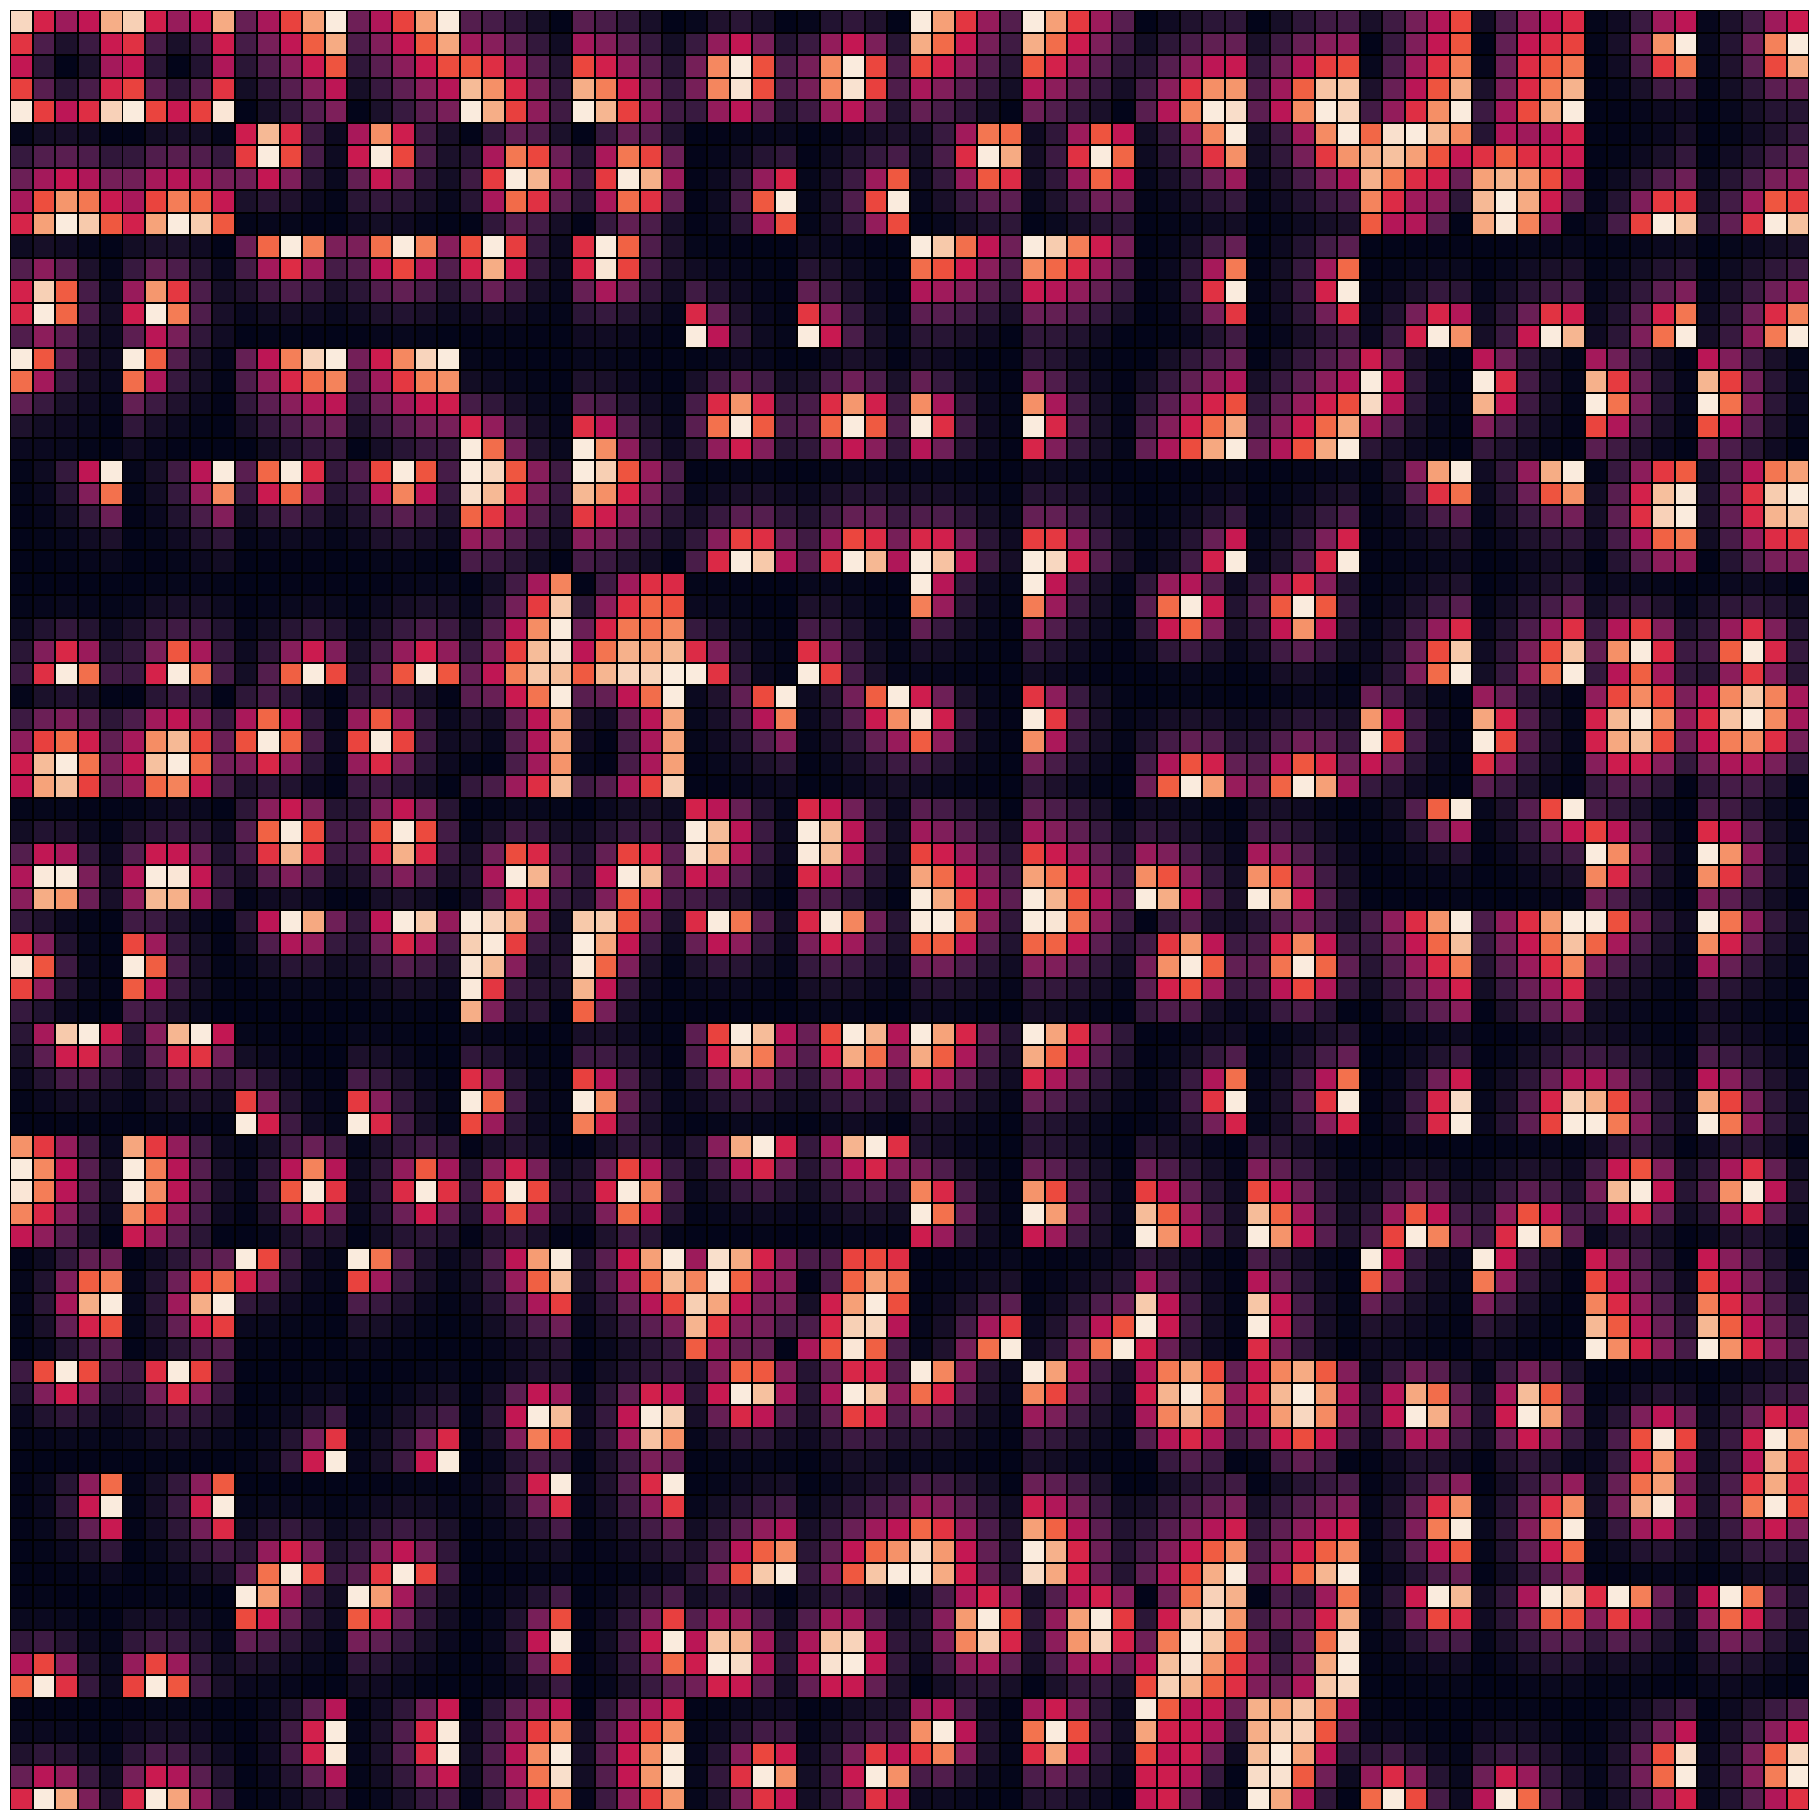

In [70]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n = centers.shape[0]
l = centers.shape[1]
c = 2
h = int(math.sqrt(l/c))
w = int(math.sqrt(l/c))
patches = np.reshape(centers, (n, c, h, w))
patches.shape

import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurazione
N_TOTAL = 128  # Numero di matrici
cols = 8       # Quante "coppie" per riga
rows = N_TOTAL // cols # 16 righe

# Prepariamo la figura: larghezza proporzionale alle coppie (2 canali), altezza alle righe
# Ogni unità è larga 2 (canali) e alta 1
fig, axes = plt.subplots(nrows=rows, ncols=cols*2, figsize=(18, 18))
plt.subplots_adjust(wspace=0.05, hspace=0.05) # Spazio minimo tra le coppie

for i in range(N_TOTAL):
    r = i // cols
    c = (i % cols) * 2 # Moltiplico per 2 perché ogni i occupa due colonne (CH1, CH2)
    
    for ch in range(2):
        ax = axes[r, c + ch]
        sns.heatmap(patches[i, ch], 
                    ax=ax, 
                    cbar=False, 
                    xticklabels=False, 
                    yticklabels=False, 
                    square=True, 
                    linewidths=0.1,
                    linecolor="black")
        ax.axis('off')

plt.tight_layout(pad=0)
plt.show()

In [74]:
extractor = ExtractorConvGP(
    device=device,
    in_channels=2, 
    out_channels=8, 
    kernel_size=5, 
    log_s=2.0,
    log_ls=2.0,
    M=M, 
    padding=2, 
    stride=2,
    name="extractor_1",
    log_path="model.log"
)

extractor.Z.data.copy_(torch.Tensor(centers))
K_zz = extractor._rbf(extractor.Z, extractor.Z, extractor.sigma, extractor.lengthscale) + 1e-5 * torch.eye(M)

extractor.m.data.copy_(torch.zeros((M, 8))+0.5)
extractor.L_S_raw.data.copy_(torch.linalg.cholesky(1e-5 * K_zz))
del K_zz
extractor.to(device).float()
activations = extractor(torch.tensor(train_ds.dataset.frames).to(device).float())

activation_patches = F.unfold(activations, 5).transpose(1, 2).reshape(-1, 25*8).detach().cpu().numpy()
print(activation_patches.shape)

activation_kmeans = KMeans(n_clusters=M, random_state=42).fit(activation_patches)

(914796, 200)


In [75]:
del activations, activation_patches
classifier = ClassifierConvGP(
        device=device,
        in_channels=8, 
        in_shape=(10, 10), 
        out_channels=2, 
        kernel_size=5,
        log_s=2.0,
        log_ls=2.0,
        M=M, 
        padding=0, 
        stride=1,
        name="classifier",
        log_path="model.log"
)
classifier.Z.data.copy_(torch.tensor(activation_kmeans.cluster_centers_))
K_zz = classifier._rbf(classifier.Z, classifier.Z, classifier.sigma, classifier.lengthscale) + 1e-5 * torch.eye(M)

classifier.m.data.copy_(torch.zeros((M, 1)) + 0.5)
classifier.L_S_raw.data.copy_(torch.linalg.cholesky(1e-5 * K_zz))
classifier.to(device).float()

ClassifierConvGP()

In [76]:
from datetime import datetime

def train_one_epoch(model, epoch_index): 
    running_loss = 0.
    last_loss = 0.
    running_nll = 0
    last_nll = 0
    running_kll = 0
    last_kll = 0
    running_acc = 0.
    last_acc = 0.
    running_F1 = 0.
    last_F1 = 0.
    len_ds = len(train_ds)
    for i, data in enumerate(train_ds):
        inputs, labels = data
        inputs = inputs.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        loss, nll, kll, acc, F1 = elbo_loss(model, inputs, labels, beta=0, dataset_size=len_ds, verbose=False)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        running_nll += nll.item()
        running_kll += kll.item()
        running_acc += acc.item()
        running_F1 += F1.item()
        
        if i == len_ds - 1:
            last_loss = running_loss / len_ds
            last_nll = running_nll / len_ds
            last_kll = running_kll / len_ds
            last_acc = running_acc / len_ds
            last_F1 = running_F1 / len_ds
    
    return last_loss, last_nll, last_kll, last_acc, last_F1


base_model = DeepCGP([
    extractor,
    classifier
]).float().to(device)

optimizer = torch.optim.Adam(base_model.parameters(), lr=0.01)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# Removed SummaryWriter initialization
epoch_number = 0

EPOCHS = 300

best_vloss = 1_000_000.
for epoch in range(EPOCHS):
    base_model.train(True)
    avg_loss, avg_nll, avg_kll, avg_acc, avg_F1 = train_one_epoch(base_model, epoch_number)


    running_vloss = 0.0
    running_vnll = 0.0
    running_vkll = 0.0
    running_vacc = 0.0
    running_vF1 = 0.0
    
    base_model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_ds):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device, non_blocking=True).float()
            vlabels = vlabels.to(device, non_blocking=True)
            vloss, vnll, vkll, vacc, vF1 = elbo_loss(base_model, vinputs, vlabels, beta=0, dataset_size=len(val_ds), verbose=False)
            running_vloss += vloss
            running_vnll += vnll
            running_vkll += vkll
            running_vacc += vacc 
            running_vF1 += vF1

    avg_vloss = running_vloss / (i + 1)
    avg_vnll = running_vnll / (i + 1)
    avg_vkll = running_vkll / (i + 1)
    avg_vacc = running_vacc / (i + 1)
    avg_vF1 = running_vF1 / (i + 1)
    print('EPOCH {}:'.format(epoch_number + 1))
    print('METRICS:\ntrain:\n\tloss: {},\n\tnll,kll: {},{},\n\taccuracy: {},\n\tF1: {}\nvalid:\n\tloss: {},\n\tnll,kll: {},{},\n\taccuracy: {},\n\tF1: {}'\
        .format(avg_loss, avg_nll, avg_kll, avg_acc, avg_F1, avg_vloss, avg_vnll, avg_vkll, avg_vacc, avg_vF1))

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'base_model'
        torch.save(base_model.state_dict(), model_path)
        print('Model saved')

    epoch_number += 1

/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_9273/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float

EPOCH 1:
METRICS:
train:
	loss: 0.6943168084525583,
	nll,kll: 0.6943168084525583,15.073125094025578,
	accuracy: 0.498364216942883,
	F1: 0.3811272849707897
valid:
	loss: 0.6937302350997925,
	nll,kll: 0.6937302350997925,104.31998443603516,
	accuracy: 0.4945771396160126,
	F1: 0.6569992899894714
Model saved
EPOCH 2:
METRICS:
train:
	loss: 0.693643207825608,
	nll,kll: 0.693643207825608,14.938729140027684,
	accuracy: 0.5019105946897862,
	F1: 0.4194467712343488
valid:
	loss: 0.6929931640625,
	nll,kll: 0.6929931640625,104.29788970947266,
	accuracy: 0.511012613773346,
	F1: 0.0
Model saved
EPOCH 3:
METRICS:
train:
	loss: 0.6935723137915434,
	nll,kll: 0.6935723137915434,15.241997100600047,
	accuracy: 0.5010207286432161,
	F1: 0.3662441499138148
valid:
	loss: 0.6929785013198853,
	nll,kll: 0.6929785013198853,112.3414535522461,
	accuracy: 0.511012613773346,
	F1: 0.0
Model saved
EPOCH 4:
METRICS:
train:
	loss: 0.6932203864032899,
	nll,kll: 0.6932203864032899,16.167665972781542,
	accuracy: 0.5058495603

KeyboardInterrupt: 

In [ ]:
from datetime import datetime
from IPython.display import clear_output
# Removed SummaryWriter import

def train_one_epoch(model, epoch_index): 
    running_loss = 0.
    last_loss = 0.
    running_nll = 0
    last_nll = 0
    running_kll = 0
    last_kll = 0
    running_acc = 0.
    last_acc = 0.
    running_F1 = 0.
    last_F1 = 0.
    len_ds = len(train_ds)
    for i, data in enumerate(train_ds):
        inputs, labels = data
        inputs = inputs.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        loss, nll, kll, acc, F1 = elbo_loss(model, inputs, labels, beta=0, dataset_size=len_ds, verbose=i==len(train_ds) - 1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        running_nll += nll.item()
        running_kll += kll.item()
        running_acc += acc.item()
        running_F1 += F1.item()
        
        if i == len_ds - 1:
            last_loss = running_loss / len_ds
            last_nll = running_nll / len_ds
            last_kll = running_kll / len_ds
            last_acc = running_acc / len_ds
            last_F1 = running_F1 / len_ds
    
    return last_loss, last_nll, last_kll, last_acc, last_F1


# Initializing timestamp for file naming
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# Removed SummaryWriter initialization
epoch_number = 0

EPOCHS = 300

best_vloss = 1_000_000.
M = 32
model = DeepCGP([
    ExtractorConvGP(
        device=device,
        in_channels=2, 
        out_channels=8, 
        kernel_size=5, 
        log_s=2.0,
        log_ls=2.0,
        M=M, 
        padding=2, 
        stride=2,
        name="extractor_1",
        log_path="model.log"
    ),
    ExtractorConvGP(
        device=device,
        in_channels=8,
        out_channels=16,
        kernel_size=3, 
        log_s=2.0,
        log_ls=2.0,
        M=M, 
        padding=1, 
        stride=1,
        name="extractor_2",
        log_path="model.log"
    ),
    ClassifierConvGP(
        device=device,
        in_channels=16, 
        in_shape=(10, 10), 
        out_channels=2, 
        kernel_size=5,
        log_s=2.0,
        log_ls=2.0,
        M=M, 
        padding=0, 
        stride=1,
        name="classifier",
        log_path="model.log"
    )
]).float().to(device)

model.initialize_inducing_points(train_ds)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # <--- End list of param groups
for epoch in range(EPOCHS):
    #clear_output(wait=True)
    

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss, avg_nll, avg_kll, avg_acc, avg_F1 = train_one_epoch(model, epoch_number) # Removed writer argument


    running_vloss = 0.0
    running_vnll = 0.0
    running_vkll = 0.0
    running_vacc = 0.0
    running_vF1 = 0.0
    
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_ds):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device, non_blocking=True).float()
            vlabels = vlabels.to(device, non_blocking=True)
            vloss, vnll, vkll, vacc, vF1 = elbo_loss(model, vinputs, vlabels, beta=0, dataset_size=len(val_ds), verbose=i==len(val_ds) - 1)
            running_vloss += vloss
            running_vnll += vnll
            running_vkll += vkll
            running_vacc += vacc 
            running_vF1 += vF1

    avg_vloss = running_vloss / (i + 1)
    avg_vnll = running_vnll / (i + 1)
    avg_vkll = running_vkll / (i + 1)
    avg_vacc = running_vacc / (i + 1)
    avg_vF1 = running_vF1 / (i + 1)
    print('EPOCH {}:'.format(epoch_number + 1))
    print('METRICS:\ntrain:\n\tloss: {},\n\tnll,kll: {},{},\n\taccuracy: {},\n\tF1: {}\nvalid:\n\tloss: {},\n\tnll,kll: {},{},\n\taccuracy: {},\n\tF1: {}'\
        .format(avg_loss, avg_nll, avg_kll, avg_acc, avg_F1, avg_vloss, avg_vnll, avg_vkll, avg_vacc, avg_vF1))

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model'
        torch.save(model.state_dict(), model_path)
        print('Model saved')

    epoch_number += 1

/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).

mean: tensor([[-0.0494, -0.1182],
        [-0.0621, -0.1279],
        [-0.0503, -0.1172]], device='cuda:0', grad_fn=<PermuteBackward0>),
 var:tensor([[0.0140, 0.0139],
        [0.0157, 0.0157],
        [0.0133, 0.0133]], device='cuda:0', grad_fn=<ClampBackward1>),
w: tensor([0.0041, 0.0020, 0.0027, 0.0057, 0.0020, 0.0026, 0.0091, 0.1110, 0.0381,
        0.0228, 0.0376, 0.0103, 0.0016, 0.0464, 0.0141, 0.2132, 0.0309, 0.0026,
        0.0038, 0.0239, 0.0064, 0.0136, 0.0851, 0.0045, 0.0015, 0.0875, 0.0137,
        0.0617, 0.0437, 0.0007, 0.0182, 0.0063, 0.0074, 0.0030, 0.0606, 0.0014],
       device='cuda:0', grad_fn=<SoftmaxBackward0>),
Z: Parameter containing:
tensor([[-1.3851, -0.9443, -4.0204,  ...,  1.1680,  2.0901, -1.7732],
        [ 0.1456,  0.8387,  0.9862,  ...,  0.4440,  1.6479, -0.6614],
        [ 1.2995, -0.0870, -0.9588,  ...,  1.1609, -2.2110,  0.6369],
        ...,
        [ 1.6746, -1.1795, -0.2988,  ..., -0.7819, -0.4219, -1.3211],
        [ 0.9370, -2.1058,  2.6122,  ...

/tmp/ipykernel_33143/590307568.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])


mean: tensor([[-0.0615, -0.1079],
        [-0.0605, -0.1081],
        [-0.0578, -0.1141],
        [-0.0650, -0.1102],
        [-0.0663, -0.1110],
        [-0.0661, -0.1119],
        [-0.0589, -0.1049],
        [-0.0588, -0.1090],
        [-0.0564, -0.1082],
        [-0.0663, -0.1086],
        [-0.0642, -0.1103],
        [-0.0622, -0.1054],
        [-0.0602, -0.1055],
        [-0.0647, -0.1101],
        [-0.0631, -0.1077],
        [-0.0654, -0.1146],
        [-0.0579, -0.1156],
        [-0.0647, -0.1075],
        [-0.0623, -0.1151],
        [-0.0577, -0.1096],
        [-0.0615, -0.1114],
        [-0.0676, -0.1102],
        [-0.0637, -0.1178],
        [-0.0607, -0.1119],
        [-0.0608, -0.1117],
        [-0.0643, -0.1103],
        [-0.0643, -0.1145],
        [-0.0576, -0.1088],
        [-0.0631, -0.1101],
        [-0.0605, -0.1114],
        [-0.0610, -0.1127],
        [-0.0651, -0.1092],
        [-0.0578, -0.1122],
        [-0.0626, -0.1091],
        [-0.0596, -0.1100],
        [-0.06

KeyboardInterrupt: 